In [59]:
### Load VsN data

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

EffClr = [0.2,0.2,0.8]
CurrClr = [0.8,0.2,0.2]
CondClr = [0,0,0]
CorrColor = [.15,.6,.15]
AsynchColor = [.6,.2,.6]

XClr = [.2,.75,.2]


CorrClrs = [CorrColor,AsynchColor]

ApproxName = r'eff. $\tau$ approx.'

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size']=12

DataDir = './Data/'
ImagesDir = './Image/'


VsNFilename = 'VsNPlotData.npy'


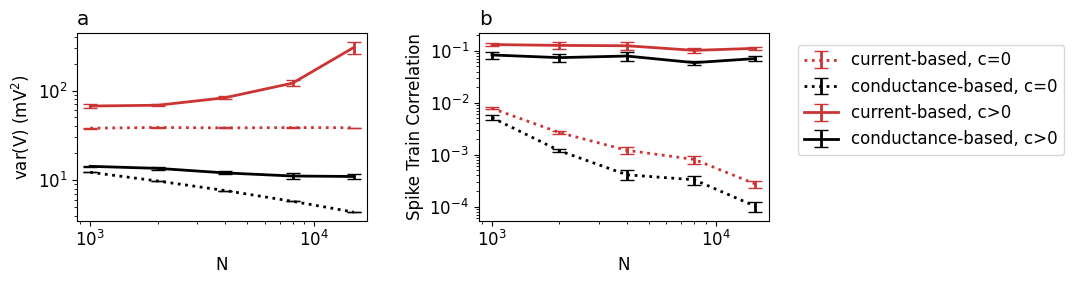

In [60]:
#####
## First Vs N figure
#####

#plotdata = np.load('VsNplotData.npy', allow_pickle=True).item()

plotdata = np.load(DataDir+VsNFilename, allow_pickle=True).item()

Ns = plotdata['Ns']
cs = plotdata['cs']
storeVarVeCond = plotdata['storeVarVeCond']
storeVarVeEff = plotdata['storeVarVeEff']
storeVarVe = plotdata['storeVarVe']

storeStdVeCond = np.sqrt(storeVarVeCond)
storeStdVeEff = np.sqrt(storeVarVeEff)
storeStdVe = np.sqrt(storeVarVe)

#storeVarVeCondFree = plotdata['storeVarVeCondFree']
#storeVarVeEffFree = plotdata['storeVarVeEffFree']
#storeVarVeFree = plotdata['storeVarVeFree']
T = plotdata['T']
#T=5250
#totaltime = plotdata['totaltime']

StoreCorrSS = plotdata['StoreCorrSS']
StoreCorrSSCond = plotdata['StoreCorrSSCond']
StoreCorrSSEff = plotdata['StoreCorrSSEff']

StoreShuffledCorrSS = plotdata['StoreShuffledCorrSS']
StoreShuffledCorrSSCond = plotdata['StoreShuffledCorrSSCond']
StoreShuffledCorrSSEff = plotdata['StoreShuffledCorrSSEff']

numtrials = plotdata['numtrials']


fig, axs = plt.subplots(1,2, figsize=(11,3))

# VAR V PLOTS
axs[0].errorbar(Ns, storeVarVe[:,:,0].mean(axis = 0), storeVarVe[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label='current-based, c=0', color=CurrClr, lw=2)
axs[0].errorbar(Ns, storeVarVeCond[:,:,0].mean(axis = 0), storeVarVeCond[:,:,0].std(axis = 0)/np.sqrt(numtrials),linestyle=':', capsize=5, label='conductance-based, c=0', color=CondClr, lw=2)
axs[0].errorbar(Ns, storeVarVe[:,:,1].mean(axis = 0), storeVarVe[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='current-based, c>0', color=CurrClr, lw=2)
axs[0].errorbar(Ns, storeVarVeCond[:,:,1].mean(axis = 0), storeVarVeCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based, c>0', color=CondClr, lw=2)
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel('N')
axs[0].set_ylabel(r'var(V) (mV$^2$)')
#axs[0].legend(loc=(0.15,0.5))
#axs[0,0].set_ylim(bottom=25)
#axs[0,1].set_ylim(top=21)

# # SPIKE CORR PLOTS
axs[1].errorbar(Ns, StoreCorrSS[:,:,0].mean(axis = 0), StoreCorrSS[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label='current-based, c=0', color=CurrClr, lw=2)
axs[1].errorbar(Ns, StoreCorrSSCond[:,:,0].mean(axis = 0), StoreCorrSSCond[:,:,0].std(axis = 0)/np.sqrt(numtrials),linestyle=':', capsize=5, label='conductance-based, c=0', color=CondClr, lw=2)
axs[1].errorbar(Ns, StoreCorrSS[:,:,1].mean(axis = 0), StoreCorrSS[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='current-based, c>0', color=CurrClr, lw=2)
axs[1].errorbar(Ns, StoreCorrSSCond[:,:,1].mean(axis = 0), StoreCorrSSCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based, c>0', color=CondClr, lw=2)
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_xlabel('N')
axs[1].set_ylabel('\nSpike Train Correlation')

axs[1].legend(loc=(1.1,0.35))
axs[0].set_title('a',loc='left')
axs[1].set_title('b',loc='left')
fig.tight_layout()

plt.savefig(ImagesDir+'VsN2x2.svg')
plt.savefig(ImagesDir+'VsN2x2.pdf')
plt.savefig(ImagesDir+'VsN2x2.jpg')



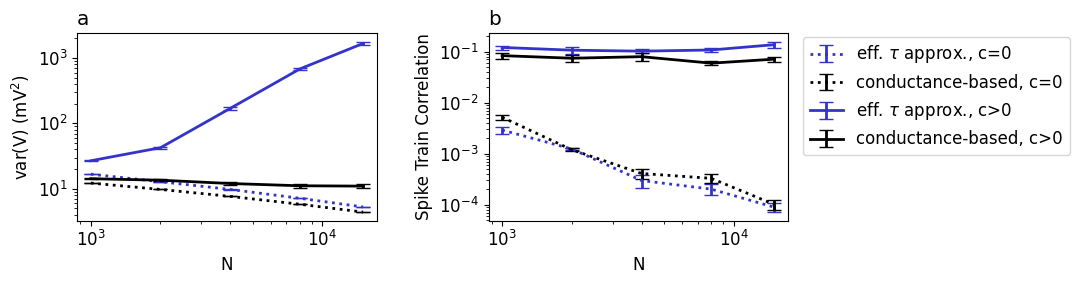

In [61]:
#####
## Approx figure
#####

#plotdata = np.load('VsNplotData.npy', allow_pickle=True).item()



fig, axs = plt.subplots(1,2, figsize=(11,3))

# VAR V PLOTS
axs[0].errorbar(Ns, storeVarVeEff[:,:,0].mean(axis = 0), storeVarVeEff[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label=ApproxName+', c=0', color=EffClr, lw=2)
axs[0].errorbar(Ns, storeVarVeCond[:,:,0].mean(axis = 0), storeVarVeCond[:,:,0].std(axis = 0)/np.sqrt(numtrials),linestyle=':', capsize=5, label='conductance-based, c=0', color=CondClr, lw=2)
axs[0].errorbar(Ns, storeVarVeEff[:,:,1].mean(axis = 0), storeVarVeEff[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+', c>0', color=EffClr, lw=2)
axs[0].errorbar(Ns, storeVarVeCond[:,:,1].mean(axis = 0), storeVarVeCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based, c>0', color=CondClr, lw=2)
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_xlabel('N')
axs[0].set_ylabel(r'var(V) (mV$^2$)')
#axs[0].legend(loc=(0.15,0.5))
#axs[0,0].set_ylim(bottom=25)
#axs[0,1].set_ylim(top=21)

# # SPIKE CORR PLOTS
axs[1].errorbar(Ns, StoreCorrSSEff[:,:,0].mean(axis = 0), StoreCorrSSEff[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label=ApproxName+', c=0', color=EffClr, lw=2)
axs[1].errorbar(Ns, StoreCorrSSCond[:,:,0].mean(axis = 0), StoreCorrSSCond[:,:,0].std(axis = 0)/np.sqrt(numtrials),linestyle=':', capsize=5, label='conductance-based, c=0', color=CondClr, lw=2)
axs[1].errorbar(Ns, StoreCorrSSEff[:,:,1].mean(axis = 0), StoreCorrSSEff[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+', c>0', color=EffClr, lw=2)
axs[1].errorbar(Ns, StoreCorrSSCond[:,:,1].mean(axis = 0), StoreCorrSSCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based, c>0', color=CondClr, lw=2)
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_xlabel('N')
axs[1].set_ylabel('\nSpike Train Correlation')

axs[1].legend(loc=(1.05,0.35))
axs[0].set_title('a',loc='left')
axs[1].set_title('b',loc='left')
fig.tight_layout()


fig.savefig(ImagesDir+'VsNapprox.svg', bbox_inches='tight')
fig.savefig(ImagesDir+'VsNapprox.pdf', bbox_inches='tight')
fig.savefig(ImagesDir+'VsNapprox.jpg', bbox_inches='tight')




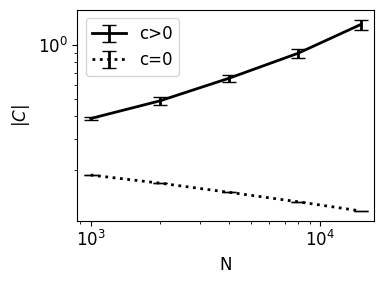

In [62]:

#plotdata = np.load('VsNplotData.npy', allow_pickle=True).item()


storeAbsErrorTerm = plotdata['storeAbsErrorTerm']

plt.figure(figsize=(4,3))



# # Err PLOTS
plt.errorbar(Ns, storeAbsErrorTerm[:,:,1].mean(axis = 0), storeAbsErrorTerm[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='c>0', color=CondClr, lw=2)
plt.errorbar(Ns, storeAbsErrorTerm[:,:,0].mean(axis = 0), storeAbsErrorTerm[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label='c=0', color=CondClr, lw=2)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('N')
plt.ylabel(r'$|C|$')
plt.legend()


# #axs[1,0].legend(loc=(1.05,0.35))
# axs[0,0].set_title('a',loc='left')
# axs[1,0].set_title('b',loc='left')
# axs[1,1].set_title('c',loc='left')

plt.tight_layout()


plt.savefig(ImagesDir+'ErrorVsN.svg', bbox_inches='tight')
plt.savefig(ImagesDir+'ErrorVsN.pdf', bbox_inches='tight')
plt.savefig(ImagesDir+'ErrorVsN.jpg', bbox_inches='tight')




In [63]:

# #plotdata = np.load('VsNplotData.npy', allow_pickle=True).item()


# storeAbsErrorTerm = plotdata['storeAbsErrorTerm']

# fig, axs = plt.subplots(2,2, figsize=(8,5.5))

# # VAR V PLOTS
# axs[0,0].errorbar(Ns, storeVarVeEff[:,:,0].mean(axis = 0), storeVarVeEff[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label=ApproxName+', c=0', color=EffClr, lw=2)
# axs[0,0].errorbar(Ns, storeVarVeCond[:,:,0].mean(axis = 0), storeVarVeCond[:,:,0].std(axis = 0)/np.sqrt(numtrials),linestyle=':', capsize=5, label='conductance-based, c=0', color=CondClr, lw=2)
# axs[0,0].errorbar(Ns, storeVarVeEff[:,:,1].mean(axis = 0), storeVarVeEff[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+', c>0', color=EffClr, lw=2)
# axs[0,0].errorbar(Ns, storeVarVeCond[:,:,1].mean(axis = 0), storeVarVeCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based, c>0', color=CondClr, lw=2)
# axs[0,0].set_yscale('log')
# axs[0,0].set_xscale('log')
# axs[0,0].set_xlabel('N')
# axs[0,0].set_ylabel(r'var(V) (mV$^2$)')

# # make axs[0,1] an empty subplot and draw the legend from axs[0,0] there
# axs[0,1].axis('off')
# axs[0,1].legend(*axs[0,0].get_legend_handles_labels(), loc='center')


# # # SPIKE CORR PLOTS
# axs[1,0].errorbar(Ns, StoreCorrSSEff[:,:,0].mean(axis = 0), StoreCorrSSEff[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label=ApproxName+', c=0', color=EffClr, lw=2)
# axs[1,0].errorbar(Ns, StoreCorrSSCond[:,:,0].mean(axis = 0), StoreCorrSSCond[:,:,0].std(axis = 0)/np.sqrt(numtrials),linestyle=':', capsize=5, label='conductance-based, c=0', color=CondClr, lw=2)
# axs[1,0].errorbar(Ns, StoreCorrSSEff[:,:,1].mean(axis = 0), StoreCorrSSEff[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+', c>0', color=EffClr, lw=2)
# axs[1,0].errorbar(Ns, StoreCorrSSCond[:,:,1].mean(axis = 0), StoreCorrSSCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based, c>0', color=CondClr, lw=2)
# axs[1,0].set_yscale('log')
# axs[1,0].set_xscale('log')
# axs[1,0].set_xlabel('N')
# axs[1,0].set_ylabel('\nSpike Train Correlation')



# # # Err PLOTS
# axs[1,1].errorbar(Ns, storeAbsErrorTerm[:,:,0].mean(axis = 0), storeAbsErrorTerm[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5,linestyle=':', label=ApproxName+', c=0', color=CondClr, lw=2)
# axs[1,1].errorbar(Ns, storeAbsErrorTerm[:,:,1].mean(axis = 0), storeAbsErrorTerm[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+', c>0', color=CondClr, lw=2)
# axs[1,1].set_yscale('log')
# axs[1,1].set_xscale('log')
# axs[1,1].set_xlabel('N')
# axs[1,1].set_ylabel(r'$\Gamma$')



# #axs[1,0].legend(loc=(1.05,0.35))
# axs[0,0].set_title('a',loc='left')
# axs[1,0].set_title('b',loc='left')
# axs[1,1].set_title('c',loc='left')

# fig.tight_layout()


# fig.savefig(ImagesDir+'VsNapprox.svg', bbox_inches='tight')
# fig.savefig(ImagesDir+'VsNapprox.pdf', bbox_inches='tight')
# fig.savefig(ImagesDir+'VsNapprox.jpg', bbox_inches='tight')




In [64]:
# #####
# ## First Vs N figure
# #####

# #plotdata = np.load('VsNplotData.npy', allow_pickle=True).item()

# plotdata = np.load(DataDir+VsNFilename, allow_pickle=True).item()

# Ns = plotdata['Ns']
# cs = plotdata['cs']
# storeVarVeCond = plotdata['storeVarVeCond']
# storeVarVeEff = plotdata['storeVarVeEff']
# storeVarVe = plotdata['storeVarVe']

# storeStdVeCond = np.sqrt(storeVarVeCond)
# storeStdVeEff = np.sqrt(storeVarVeEff)
# storeStdVe = np.sqrt(storeVarVe)

# #storeVarVeCondFree = plotdata['storeVarVeCondFree']
# #storeVarVeEffFree = plotdata['storeVarVeEffFree']
# #storeVarVeFree = plotdata['storeVarVeFree']
# T = plotdata['T']
# #T=5250
# #totaltime = plotdata['totaltime']

# StoreCorrSS = plotdata['StoreCorrSS']
# StoreCorrSSCond = plotdata['StoreCorrSSCond']
# StoreCorrSSEff = plotdata['StoreCorrSSEff']

# StoreShuffledCorrSS = plotdata['StoreShuffledCorrSS']
# StoreShuffledCorrSSCond = plotdata['StoreShuffledCorrSSCond']
# StoreShuffledCorrSSEff = plotdata['StoreShuffledCorrSSEff']

# numtrials = plotdata['numtrials']

# print(numtrials,cs,Ns,T)


# fig, axs = plt.subplots(2,2, figsize=(7,5))

# # VAR V PLOTS
# axs[0,0].set_ylabel(r'var(V) (mV$^2$)')
# for j in range(2):
#     axs[0,0].errorbar(Ns, storeVarVe[:,:,j].mean(axis = 0), storeVarVe[:,:,j].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='c ='+str(cs[j]), color=CorrClrs[j], lw=2)
#     axs[0,1].errorbar(Ns, storeVarVeCond[:,:,j].mean(axis = 0), storeVarVeCond[:,:,j].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CorrClrs[j], lw=2)
#     #axs[0,1].errorbar(Ns, storeVarVeEff[:,:,j].mean(axis = 0), storeVarVeEff[:,:,j].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CorrClrs[j], linestyle='--')
# #axs[0,0].set(xlabel='N')
# #axs[0,1].set(xlabel='N')
# for j in range(2):
#     axs[0,j].set_yscale('log')
#     axs[0,j].set_xscale('log')
# axs[0,0].set_title('Current-based')
# axs[0,1].set_title('Conductance-based')
# axs[0,0].legend()
# #axs[0,0].set_ylim(bottom=25)
# #axs[0,1].set_ylim(top=21)

# # SPIKE CORR PLOTS
# axs[1,0].set_ylabel('Spike Train Correlation')
# for j in range(2):
#     axs[1,0].errorbar(Ns, StoreCorrSS[:,:,j].mean(axis = 0), StoreCorrSS[:,:,j].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='c ='+str(cs[j]), color=CorrClrs[j], lw=2)
#     axs[1,1].errorbar(Ns, StoreCorrSSCond[:,:,j].mean(axis = 0), StoreCorrSSCond[:,:,j].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CorrClrs[j], lw=2)
#     #axs[1,1].errorbar(Ns, StoreCorrSSEff[:,:,j].mean(axis = 0), StoreCorrSSEff[:,:,j].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CorrClrs[j], linestyle='--')
# # Shuffled
# #axs[1,0].errorbar(Ns, StoreShuffledCorrSS[:,:,0].mean(axis = 0), StoreShuffledCorrSS[:,:,j].std(axis = 0)/np.sqrt(numtrials), linestyle=':', capsize=5, color=CorrClrs[0], lw=2)
# #axs[1,1].errorbar(Ns, StoreShuffledCorrSSCond[:,:,0].mean(axis = 0), StoreShuffledCorrSSCond[:,:,j].std(axis = 0)/np.sqrt(numtrials), linestyle=':', capsize=5, color=CorrClrs[0], lw=2)
# axs[1,0].set(xlabel='N')
# axs[1,1].set(xlabel='N')
# for j in range(2):
#     axs[1,j].set_yscale('log')
#     axs[1,j].set_xscale('log')
# #axs[1,0].set_title('Current-based')
# #axs[1,1].set_title('Conductance-based')
# #axs[1,0].legend()

# #axs[1,0].set_ylim((.0085,.115))
# #axs[1,1].set_ylim((.0085,.115))

# axs[0,0].set_title('a',loc='left')
# axs[1,0].set_title('b',loc='left')
# axs[0,1].set_title('c',loc='left')
# axs[1,1].set_title('d',loc='left')

# #sns.despine()

# fig.tight_layout()

# plt.savefig(ImagesDir+'VsN2x2.svg')
# plt.savefig(ImagesDir+'VsN2x2.pdf')
# plt.savefig(ImagesDir+'VsN2x2.jpg')



In [65]:
# #####
# ## First Vs N figure
# #####

# #plotdata = np.load('VsNplotData.npy', allow_pickle=True).item()

# plotdata = np.load(DataDir+VsNFilename, allow_pickle=True).item()

# Ns = plotdata['Ns']
# cs = plotdata['cs']
# storeVarVeCond = plotdata['storeVarVeCond']
# storeVarVeEff = plotdata['storeVarVeEff']
# storeVarVe = plotdata['storeVarVe']

# storeStdVeCond = np.sqrt(storeVarVeCond)
# storeStdVeEff = np.sqrt(storeVarVeEff)
# storeStdVe = np.sqrt(storeVarVe)

# #storeVarVeCondFree = plotdata['storeVarVeCondFree']
# #storeVarVeEffFree = plotdata['storeVarVeEffFree']
# #storeVarVeFree = plotdata['storeVarVeFree']
# T = plotdata['T']
# #T=5250
# #totaltime = plotdata['totaltime']

# StoreCorrSS = plotdata['StoreCorrSS']
# StoreCorrSSCond = plotdata['StoreCorrSSCond']
# StoreCorrSSEff = plotdata['StoreCorrSSEff']

# StoreShuffledCorrSS = plotdata['StoreShuffledCorrSS']
# StoreShuffledCorrSSCond = plotdata['StoreShuffledCorrSSCond']
# StoreShuffledCorrSSEff = plotdata['StoreShuffledCorrSSEff']

# numtrials = plotdata['numtrials']

# print(numtrials,cs,Ns,T)


# fig, axs = plt.subplots(2,2, figsize=(7,5))

# # VAR V PLOTS
# axs[0,0].set_ylabel(r'var(V) (mV$^2$)')
# axs[0,0].errorbar(Ns, storeVarVe[:,:,0].mean(axis = 0), storeVarVe[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='current-based', color=CurrClr, lw=2)
# axs[0,0].errorbar(Ns, storeVarVeCond[:,:,0].mean(axis = 0), storeVarVeCond[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based', color=CondClr, lw=2)
# axs[0,1].errorbar(Ns, storeVarVe[:,:,1].mean(axis = 0), storeVarVe[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CurrClr, lw=2)
# axs[0,1].errorbar(Ns, storeVarVeCond[:,:,1].mean(axis = 0), storeVarVeCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CondClr, lw=2)

# #axs[0,0].set(xlabel='N')
# #axs[0,1].set(xlabel='N')
# for j in range(2):
#     axs[0,j].set_yscale('log')
#     axs[0,j].set_xscale('log')
# axs[0,0].set_title('c=0')
# axs[0,1].set_title('c>0')
# axs[0,0].legend(loc=(0.15,0.5))
# #axs[0,0].set_ylim(bottom=25)
# #axs[0,1].set_ylim(top=21)

# # SPIKE CORR PLOTS
# axs[1,0].set_ylabel('Spike Train Correlation')


# axs[1,0].errorbar(Ns, StoreCorrSS[:,:,0].mean(axis = 0), StoreCorrSS[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='current-based', color=CurrClr, lw=2)
# axs[1,0].errorbar(Ns, StoreCorrSSCond[:,:,0].mean(axis = 0), StoreCorrSSCond[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based', color=CondClr, lw=2)
# axs[1,1].errorbar(Ns, StoreCorrSS[:,:,1].mean(axis = 0), StoreCorrSS[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CurrClr, lw=2)
# axs[1,1].errorbar(Ns, StoreCorrSSCond[:,:,1].mean(axis = 0), StoreCorrSSCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, color=CondClr, lw=2)

# # # Shuffled
# # axs[1,0].errorbar(Ns, StoreShuffledCorrSS[:,:,0].mean(axis = 0), StoreShuffledCorrSS[:,:,0].std(axis = 0)/np.sqrt(numtrials), linestyle=':', capsize=5, color=CondClr, lw=2)
# # axs[1,0].errorbar(Ns, StoreShuffledCorrSSCond[:,:,0].mean(axis = 0), StoreShuffledCorrSSCond[:,:,0].std(axis = 0)/np.sqrt(numtrials), linestyle=':', capsize=5, color=CurrClr, lw=2)

# axs[1,0].set(xlabel='N')
# axs[1,1].set(xlabel='N')
# for j in range(2):
#     axs[1,j].set_yscale('log')
#     axs[1,j].set_xscale('log')
# #axs[1,0].set_title('Current-based')
# #axs[1,1].set_title('Conductance-based')
# #axs[1,0].legend()

# axs[1,1].set_ylim((.008,.15))
# axs[0,1].set_ylim(bottom=8)
# axs[0,0].set_ylim(top=50)

# axs[0,0].set_title('a',loc='left')
# axs[1,0].set_title('b',loc='left')
# axs[0,1].set_title('c',loc='left')
# axs[1,1].set_title('d',loc='left')

# #sns.despine()

# fig.tight_layout()

# plt.savefig(ImagesDir+'VsN2x2.svg')
# plt.savefig(ImagesDir+'VsN2x2.pdf')
# plt.savefig(ImagesDir+'VsN2x2.jpg')



In [66]:
# #####
# ## Second Vs N figure
# #####


# plotdata = np.load(DataDir+VsNFilename, allow_pickle=True).item()

# Ns = plotdata['Ns']
# cs = plotdata['cs']
# storeVarVeCond = plotdata['storeVarVeCond']
# storeVarVeEff = plotdata['storeVarVeEff']
# storeVarVe = plotdata['storeVarVe']
# T = plotdata['T']
# #totaltime = plotdata['totaltime']

# StoreCorrSS = plotdata['StoreCorrSS']
# StoreCorrSSCond = plotdata['StoreCorrSSCond']
# StoreCorrSSEff = plotdata['StoreCorrSSEff']

# numtrials = plotdata['numtrials']

# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(4,2))
# ax.set_ylabel(r'var(V) (mV$^2$)')
# ax.errorbar(Ns, storeVarVeCond[:,:,0].mean(axis = 0), storeVarVeCond[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based; c = 0', linestyle='--', color=CondClr, lw=1.5)
# ax.errorbar(Ns, storeVarVeEff[:,:,0].mean(axis = 0), storeVarVeEff[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+'; c = 0', linestyle='--', color=EffClr, lw=1.5)
# ax.errorbar(Ns, storeVarVeCond[:,:,1].mean(axis = 0), storeVarVeCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based; c ='+str(cs[1]), color=CondClr, lw=1.5)
# ax.errorbar(Ns, storeVarVeEff[:,:,1].mean(axis = 0), storeVarVeEff[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName+'; c ='+str(cs[1]), color=EffClr, lw=1.5)
# ax.set_xlabel('N')
# ax.set_yscale('log')
# ax.set_xscale('log')
# # Place legend outside right of plot
# ax.legend(loc='center left', bbox_to_anchor=(1.03, 0.5))
# fig.tight_layout()
# fig.subplots_adjust(right=0.7)  # Increase right margin to fit legend

# fig.savefig(ImagesDir+'VsNapprox.svg', bbox_inches='tight')
# fig.savefig(ImagesDir+'VsNapprox.pdf', bbox_inches='tight')
# fig.savefig(ImagesDir+'VsNapprox.jpg', bbox_inches='tight')



In [67]:
# #####
# ## Second Vs N figure
# #####


# plotdata = np.load(DataDir+VsNFilename, allow_pickle=True).item()

# Ns = plotdata['Ns']
# cs = plotdata['cs']
# storeVarVeCond = plotdata['storeVarVeCond']
# storeVarVeEff = plotdata['storeVarVeEff']
# storeVarVe = plotdata['storeVarVe']
# T = plotdata['T']
# #totaltime = plotdata['totaltime']

# StoreCorrSS = plotdata['StoreCorrSS']
# StoreCorrSSCond = plotdata['StoreCorrSSCond']
# StoreCorrSSEff = plotdata['StoreCorrSSEff']

# numtrials = plotdata['numtrials']

# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(1,2,figsize=(8.5,2.75))
# ax[0].set_ylabel(r'var(V) (mV$^2$)')
# ax[0].errorbar(Ns, storeVarVeCond[:,:,0].mean(axis = 0), storeVarVeCond[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based',  color=CondClr, lw=1.5)
# ax[0].errorbar(Ns, storeVarVeEff[:,:,0].mean(axis = 0), storeVarVeEff[:,:,0].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName,  color=EffClr, lw=1.5)
# ax[1].errorbar(Ns, storeVarVeCond[:,:,1].mean(axis = 0), storeVarVeCond[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label='conductance-based', color=CondClr, lw=1.5)
# ax[1].errorbar(Ns, storeVarVeEff[:,:,1].mean(axis = 0), storeVarVeEff[:,:,1].std(axis = 0)/np.sqrt(numtrials), capsize=5, label=ApproxName, color=EffClr, lw=1.5)
# ax[0].set_xlabel('N')
# ax[1].set_xlabel('N')
# ax[0].set_yscale('log')
# ax[0].set_xscale('log')
# ax[1].set_yscale('log')
# ax[1].set_xscale('log')
# ax[0].set_title('c=0')
# ax[1].set_title('c>0')
# # Place legend outside right of plot
# ax[1].legend(loc=(1.05,0.5))#loc='center left', bbox_to_anchor=(1.03, 0.5))
# #fig.subplots_adjust(right=0.7)  # Increase right margin to fit legend

# ax[0].set_title('a',loc='left')
# ax[1].set_title('b',loc='left')

# fig.tight_layout()


# fig.savefig(ImagesDir+'VsNapprox.svg', bbox_inches='tight')
# fig.savefig(ImagesDir+'VsNapprox.pdf', bbox_inches='tight')
# fig.savefig(ImagesDir+'VsNapprox.jpg', bbox_inches='tight')



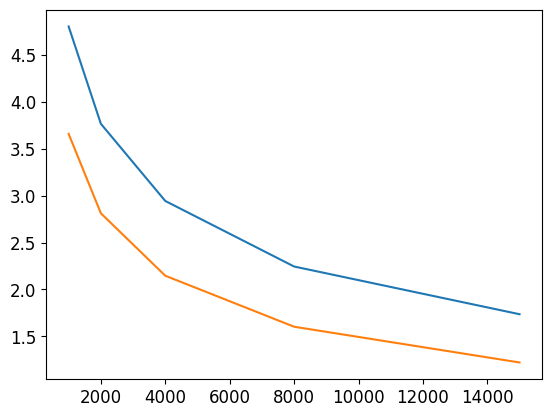

In [68]:
storegLEff = plotdata['storegLEff']

plt.plot(Ns,1/storegLEff.mean(axis=0)[:,0],label='Eff c=0')

[[0.00833333]
 [0.02083333]]


(0.0, 0.02228565350877193)

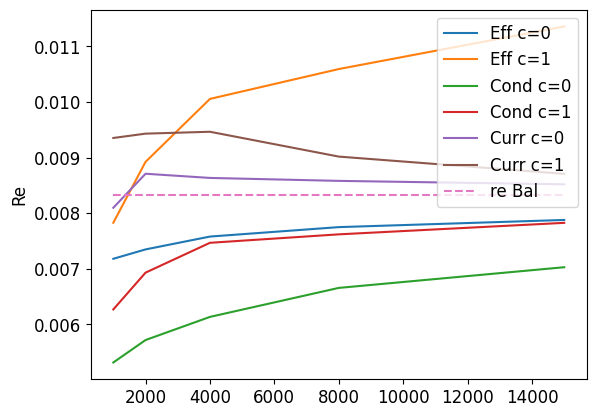

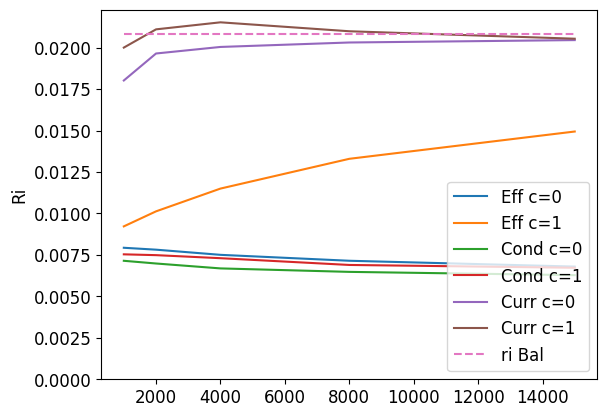

In [69]:
from default_params import *

print(rBal)



storeReEff = plotdata['storeReEff']
storeReCond = plotdata['storeReCond']
storeRe = plotdata['storeRe']
plt.plot(Ns,storeReEff.mean(axis=0)[:,0],label='Eff c=0')
plt.plot(Ns,storeReEff.mean(axis=0)[:,1],label='Eff c=1')
plt.plot(Ns,storeReCond.mean(axis=0)[:,0],label='Cond c=0')
plt.plot(Ns,storeReCond.mean(axis=0)[:,1],label='Cond c=1')
plt.plot(Ns,storeRe.mean(axis=0)[:,0],label='Curr c=0')
plt.plot(Ns,storeRe.mean(axis=0)[:,1],label='Curr c=1')
plt.plot(Ns,rBal[0]+0*Ns,label='re Bal',linestyle='--')
plt.legend()
#plt.xlabel('N')
plt.ylabel('Re')
#plt.xscale('log')

plt.figure()
storeRiEff = plotdata['storeRiEff']
storeRiCond = plotdata['storeRiCond']
storeRi = plotdata['storeRi']
plt.plot(Ns,storeRiEff.mean(axis=0)[:,0],label='Eff c=0')
plt.plot(Ns,storeRiEff.mean(axis=0)[:,1],label='Eff c=1')
plt.plot(Ns,storeRiCond.mean(axis=0)[:,0],label='Cond c=0')
plt.plot(Ns,storeRiCond.mean(axis=0)[:,1],label='Cond c=1')
plt.plot(Ns,storeRi.mean(axis=0)[:,0],label='Curr c=0')
plt.plot(Ns,storeRi.mean(axis=0)[:,1],label='Curr c=1')
plt.plot(Ns,rBal[1]+0*Ns,label='ri Bal',linestyle='--')
plt.legend()
#plt.xlabel('N')
plt.ylabel('Ri')
#plt.xscale('log')

plt.ylim(bottom=0)